In [1]:
# ============================================================
# CELL 1: Environment Setup & Repository Clone
# ============================================================
import os, subprocess, sys

# 1a. Clone the repository
REPO_URL = "https://github.com/fuen1590/PhmDeepLearningProjects.git"
REPO_DIR = "/content/PhmDeepLearningProjects"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    print(f"✅ Repository cloned to {REPO_DIR}")
else:
    print(f"ℹ️  Repository already exists at {REPO_DIR}")

# 1b. Install dependencies (from readme.md requirements)
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "torch>=2.0", "matplotlib>=3.7.0", "numpy>=1.24.3",
    "pandas>=2.0.0", "scikit-learn>=1.3.0"
], check=True)
print("✅ Dependencies installed")

# 1c. Verify dataset exists (inside the cloned repo)
DATASET_DIR = "/content/dataset"
required_files = [
    f"{prefix}_FD00{i}.txt"
    for prefix in ["train", "test", "RUL"]
    for i in range(1, 5)
]
missing = [f for f in required_files if not os.path.exists(os.path.join(DATASET_DIR, f))]
if missing:
    raise FileNotFoundError(
        f"❌ Missing files in {DATASET_DIR}: {missing}\n"
        "Upload the NASA C-MAPSS .txt files into /content/dataset/ in Colab."
    )
print(f"✅ All 12 C-MAPSS files found in {DATASET_DIR}")


ℹ️  Repository already exists at /content/PhmDeepLearningProjects
✅ Dependencies installed
✅ All 12 C-MAPSS files found in /content/dataset


In [2]:
# ============================================================
# CELL 2: Path Patching
# ============================================================
import os, re

REPO_DIR = "/content/PhmDeepLearningProjects"
DATASET_PATH = "/content/dataset/"  # standard location

# --- 2a. Patch dataset/cmapss.py ---
cmapss_path = os.path.join(REPO_DIR, "dataset", "cmapss.py")
with open(cmapss_path, "r") as f:
    cmapss_src = f.read()

# Replace DEFAULT_ROOT value (line 13)
cmapss_src = re.sub(
    r'DEFAULT_ROOT\s*=\s*r?"[^"]*"',
    f'DEFAULT_ROOT = r"{DATASET_PATH}"',
    cmapss_src
)

# Fix the regex separator: the original uses sep=r'\\s+' which produces
# the literal string \\s+ instead of the regex \s+. Colab/pandas needs
# the raw regex pattern \s+ (i.e. sep=r'\s+' or sep='\\s+').
# We normalise to sep=r'\s+' for safety.
cmapss_src = cmapss_src.replace(r"sep=r'\\s+'", r"sep=r'\s+'")

with open(cmapss_path, "w") as f:
    f.write(cmapss_src)
print(f"✅ Patched {cmapss_path}")
print(f"   DEFAULT_ROOT → {DATASET_PATH}")

# --- 2b. Patch models/RULPrediction/experiments.py ---
exp_path = os.path.join(REPO_DIR, "models", "RULPrediction", "experiments.py")
with open(exp_path, "r") as f:
    exp_src = f.read()

# Fix relative imports: experiments.py uses bare imports like
#   from SimpleModels import *
#   from MLPMixer import ...
#   from ContrastiveModules import ...
#   from BiGRU_TSAM import ...
#   from IMDSSN import ...
# These only work when CWD == models/RULPrediction.
# We convert them to fully-qualified package imports.
replacements = {
    "from SimpleModels import":     "from models.RULPrediction.SimpleModels import",
    "from MLPMixer import":         "from models.RULPrediction.MLPMixer import",
    "from BiGRU_TSAM import":       "from models.RULPrediction.BiGRU_TSAM import",
    "from IMDSSN import":           "from models.RULPrediction.IMDSSN import",
    "from ContrastiveModules import":"from models.RULPrediction.ContrastiveModules import",
}
for old, new in replacements.items():
    exp_src = exp_src.replace(old, new)

with open(exp_path, "w") as f:
    f.write(exp_src)
print(f"✅ Patched {exp_path}")
print("   Fixed bare imports → fully-qualified package imports")

# --- 2c. Patch models/RULPrediction/MLPMixer.py ---
mlpmixer_path = os.path.join(REPO_DIR, "models", "RULPrediction", "MLPMixer.py")
with open(mlpmixer_path, "r") as f:
    mlp_src = f.read()

mlp_src = mlp_src.replace(
    "from ContrastiveModules import",
    "from models.RULPrediction.ContrastiveModules import"
)
with open(mlpmixer_path, "w") as f:
    f.write(mlp_src)
print(f"✅ Patched {mlpmixer_path}")

# --- 2d. Patch models/RULPrediction/SimpleModels.py ---
simple_path = os.path.join(REPO_DIR, "models", "RULPrediction", "SimpleModels.py")
with open(simple_path, "r") as f:
    simple_src = f.read()

simple_src = simple_src.replace(
    "from ContrastiveModules import",
    "from models.RULPrediction.ContrastiveModules import"
)
with open(simple_path, "w") as f:
    f.write(simple_src)
print(f"✅ Patched {simple_path}")

# --- 2e. Patch other model files that use bare ContrastiveModules import ---
for fname in ["BiGRU_TSAM.py", "CNN_GRU.py", "DAMCNN.py", "IMDSSN.py", "ResBlockModel.py"]:
    fpath = os.path.join(REPO_DIR, "models", "RULPrediction", fname)
    if os.path.exists(fpath):
        with open(fpath, "r") as f:
            src = f.read()
        patched = src.replace(
            "from ContrastiveModules import",
            "from models.RULPrediction.ContrastiveModules import"
        )
        if patched != src:
            with open(fpath, "w") as f:
                f.write(patched)
            print(f"✅ Patched {fname}")

print("\n🎉 All path patches applied successfully!")


✅ Patched /content/PhmDeepLearningProjects/dataset/cmapss.py
   DEFAULT_ROOT → /content/dataset/
✅ Patched /content/PhmDeepLearningProjects/models/RULPrediction/experiments.py
   Fixed bare imports → fully-qualified package imports
✅ Patched /content/PhmDeepLearningProjects/models/RULPrediction/MLPMixer.py
✅ Patched /content/PhmDeepLearningProjects/models/RULPrediction/SimpleModels.py

🎉 All path patches applied successfully!


In [3]:
# ============================================================
# CELL 2b: Patch cmapss.py — Edge Pad Short Engines
# (Run AFTER Cell 2, BEFORE Cell 3)
# ============================================================
import os

REPO_DIR = "/content/PhmDeepLearningProjects"
cmapss_path = os.path.join(REPO_DIR, "dataset", "cmapss.py")

with open(cmapss_path, "r") as f:
    src = f.read()

# Normalize line endings for reliable matching
src = src.replace('\r\n', '\n')

# --- Exact block from generate_window_sample() that drops short engines ---
old_block = '''\
        if data.shape[0] < window_size:
            warnings.warn("The engine id {} with total length {} is shorter than window_size {}. "
                          "Hence, these samples were dropped!".format(_, data.shape[0], window_size))
            continue'''

new_block = '''\
        if data.shape[0] < window_size:
            # Edge Padding: repeat the first sensor row to reach window_size
            pad_size = window_size - data.shape[0]
            pad_data = np.tile(data[0:1], (pad_size, 1))
            data = np.concatenate([pad_data, data], axis=0)
            # Pad the engine DataFrame so iloc-based RUL indexing stays aligned
            pad_rows = pd.concat([engine.iloc[[0]]] * pad_size, ignore_index=True)
            engine = pd.concat([pad_rows, engine.reset_index(drop=True)], ignore_index=True)
            print(f"\\U0001f527 Padded Engine {_}: {data.shape[0] - pad_size} → {data.shape[0]} cycles (+{pad_size} padded)")'''

if old_block in src:
    new_src = src.replace(old_block, new_block)
    with open(cmapss_path, "w") as f:
        f.write(new_src)
    print("✅ Patched cmapss.py: short engines will be edge-padded instead of dropped!")
    print("   No engines will be excluded from training or evaluation.")
else:
    print("⚠️ Could not find the drop logic. The file may already be patched.")
    print("   Checking current state...")
    if "Edge Padding" in src:
        print("   ✅ Edge padding is already in place!")
    else:
        print("   ❌ Unexpected file state. Manual inspection needed.")


⚠️ Could not find the drop logic. The file may already be patched.
   Checking current state...
   ✅ Edge padding is already in place!


In [4]:
# ============================================================
# CELL 3: Import Verification
# ============================================================
import sys, os

REPO_DIR = "/content/PhmDeepLearningProjects"

# Add repo root to Python path
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Force-reload modules in case they were cached from a previous run
import importlib

import dataset.cmapss as cmapss
importlib.reload(cmapss)
from dataset.utils import compute_metrics, gaussian_distribution
import models.RULPrediction as rul
importlib.reload(rul)
from models.RULPrediction import ContrastiveModules
importlib.reload(ContrastiveModules)
from models.RULPrediction import MLPMixer as _mlpmixer_mod
importlib.reload(_mlpmixer_mod)
from models.RULPrediction.MLPMixer import MLPMixer, DualMLPMixer

import torch
import numpy as np

# Verify the path is correct
assert "/content/dataset/" in cmapss.DEFAULT_ROOT, (
    f"❌ DEFAULT_ROOT was not patched correctly! Got: {cmapss.DEFAULT_ROOT}\n"
    "   Re-run Cell 2, then restart runtime and re-run all cells."
)
print(f"✅ cmapss.DEFAULT_ROOT = '{cmapss.DEFAULT_ROOT}'")
print(f"✅ DEFAULT_SENSORS ({len(cmapss.DEFAULT_SENSORS)} sensors): {cmapss.DEFAULT_SENSORS}")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print("\n🎉 All imports verified!")


✅ cmapss.DEFAULT_ROOT = '/content/dataset/'
✅ DEFAULT_SENSORS (14 sensors): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
✅ PyTorch version: 2.10.0+cu128
✅ CUDA available: True
   GPU: Tesla T4

🎉 All imports verified!


📂 cmapss.DEFAULT_ROOT = '/content/dataset/'
  TRAINING: Dual-Mixer on C-MAPSS FD001
  Device:       cuda:0
  Window:       30
  Batch size:   1024
  Contrastive:  False
  Label norm:   True
  Mixer layers: 6
  Hidden dim:   32
  Parameters:   64,123
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
train size:14118
test size:10196
validate size:3613
Model flag: RUL-MLPDualMixer-h32-6-norm1-w30-batch1024-thresh125-FD001-neg0-1
Start training epoch 100
Visualizing samples processing...
epoch: 1/100
	training loss: 0.2779
 	eval loss: 0.1121 	Current learning rate: 0.001
	Epoch time spent: 1.9131839275360107 s
Visualizing samples processing...
epoch: 2/100
	training loss: 0.07043
 	eval loss: 0.04882 	Current learning rate: 0.001
	Epoch time spent: 1.9520866870880127 s
	Early Stopping Monitor: smaller eval loss achieved, saving model...
Visualizing samples processing...
epoch: 3/100
	training loss: 0.038
 	eval loss: 0.03283 	Current learning rate: 0.001
	Epoch time spe

/content/PhmDeepLearningProjects/models/RULPrediction/ContrastiveModules.py:222: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(self.embedding[i][:, 0], self.embedding[i][:, 1],


Total time spent: 103.64 s

🎉 Training complete! Model saved to: /content/PhmDeepLearningProjects/train/model_result/RUL-MLPDualMixer-h32-6-norm1-w30-batch1024-thresh125-FD001-neg0-1/


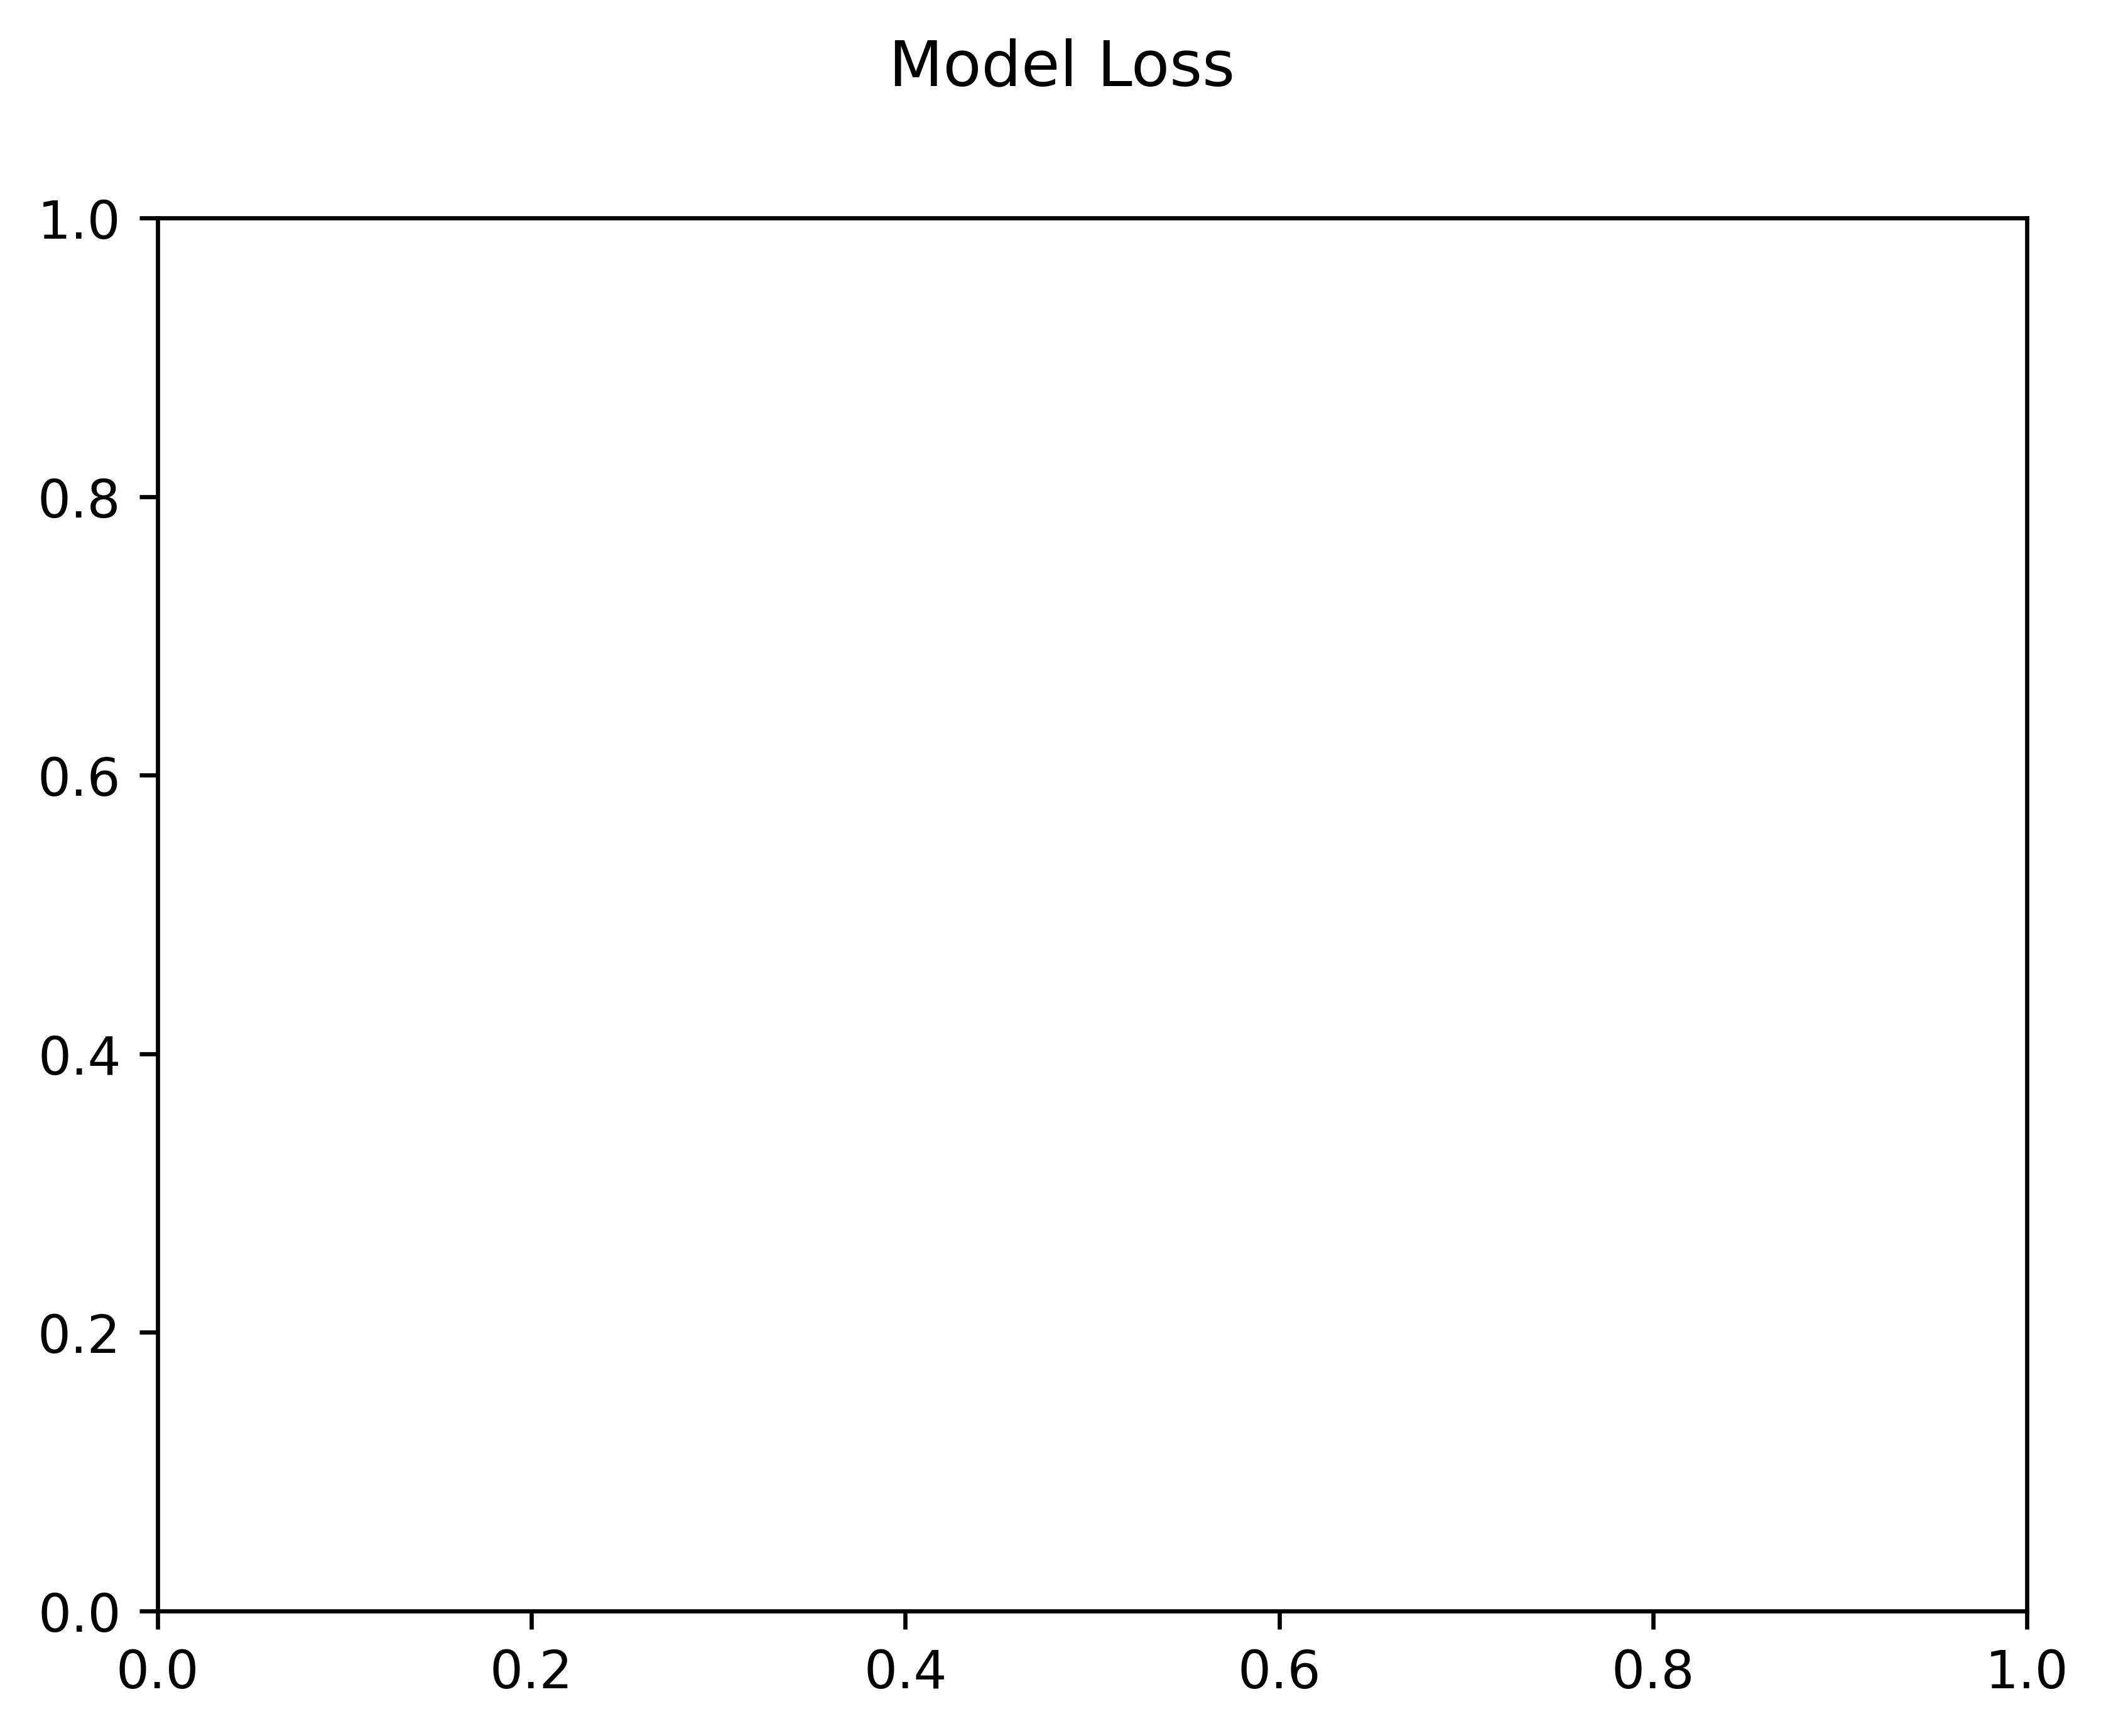

In [5]:
# ============================================================
# CELL 4: Training — Dual-Mixer Model
# ============================================================
import sys, os
REPO_DIR = "/content/PhmDeepLearningProjects"
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import importlib
import torch
import numpy as np
import dataset.cmapss as cmapss
importlib.reload(cmapss)  # ensure patched version is loaded
import models.RULPrediction as rul
from models.RULPrediction.MLPMixer import DualMLPMixer

# ── Safety net: force DEFAULT_ROOT in memory regardless of file state ──
DATASET_PATH = "/content/dataset/"
cmapss.DEFAULT_ROOT = DATASET_PATH
print(f"📂 cmapss.DEFAULT_ROOT = '{cmapss.DEFAULT_ROOT}'")
assert os.path.isdir(DATASET_PATH), f"❌ Dataset dir not found: {DATASET_PATH}"

# ===================== CONFIGURATION =====================
SUBSET        = cmapss.Subset.FD001   # Change to FD002, FD003, FD004
WINDOW_SIZE   = 30                    # Sliding window length
BATCH_SIZE    = 1024                  # Total batch size
NEG_SAMPLES   = 5                     # Negative samples for contrastive learning
CONTRASTIVE   = False                 # Set True to enable FSGRI
LABEL_NORM    = True                  # Normalize RUL labels to [0, 1]
MIXER_LAYERS  = 6                     # Number of Dual-Mixer layers
HIDDEN_DIM    = 32                    # Hidden dimension
DROPOUT       = 0                     # Dropout rate
EXP_ID        = 1                     # Experiment identifier
DEVICE        = "cuda:0" if torch.cuda.is_available() else "cpu"
# =========================================================

print("=" * 60)
print(f"  TRAINING: Dual-Mixer on C-MAPSS {SUBSET.value}")
print(f"  Device:       {DEVICE}")
print(f"  Window:       {WINDOW_SIZE}")
print(f"  Batch size:   {BATCH_SIZE}")
print(f"  Contrastive:  {CONTRASTIVE}")
print(f"  Label norm:   {LABEL_NORM}")
print(f"  Mixer layers: {MIXER_LAYERS}")
print(f"  Hidden dim:   {HIDDEN_DIM}")
print("=" * 60)

# Build model
net = DualMLPMixer(
    window_size=WINDOW_SIZE,
    in_features=len(cmapss.DEFAULT_SENSORS),
    hidden_dim=HIDDEN_DIM,
    num_layers=MIXER_LAYERS,
    dropout=DROPOUT,
    device=DEVICE,
    model_flag=f"MLPDualMixer-h{HIDDEN_DIM}-{MIXER_LAYERS}",
    label_norm=LABEL_NORM,
    filter_size=0
)

# Count parameters
total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"  Parameters:   {total_params:,}")
print("=" * 60)

# Train using the repo's built-in training pipeline
# This calls get_data() → prepares DataLoaders → trains → auto-tests
from models.RULPrediction.experiments import train_cmapss

net = train_cmapss(
    model=net,
    window_size=WINDOW_SIZE,
    neg_samples=NEG_SAMPLES,
    batch_size=BATCH_SIZE,
    subset=SUBSET,
    exp_time=EXP_ID,
    contra=CONTRASTIVE,
    label_norm=LABEL_NORM,
)

print("\n🎉 Training complete! Model saved to:", net.get_model_result_path())


In [6]:
# ============================================================
# CELL 5: Evaluation & Metrics
# ============================================================
import sys, os
REPO_DIR = "/content/PhmDeepLearningProjects"
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import numpy as np
import sklearn.metrics as me
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# --- Load test outputs saved by trainable.py ---
result_path = net.get_model_result_path()
print(f"📂 Results directory: {result_path}")
print(f"   Contents: {os.listdir(result_path)}")

# Gather all output/label parts (the framework splits large results)
outputs, labels = [], []
part = 1
while True:
    out_file = os.path.join(result_path, f"model_test_output_part{part}.npy")
    lbl_file = os.path.join(result_path, f"model_test_labels_part{part}.npy")
    if not os.path.exists(out_file):
        break
    outputs.append(np.load(out_file))
    labels.append(np.load(lbl_file))
    part += 1

pred = np.concatenate(outputs, axis=0).squeeze()
true = np.concatenate(labels, axis=0).squeeze()
print(f"\n📊 Test samples: {len(pred)}")

# --- Metrics ---
mse  = me.mean_squared_error(true, pred)
rmse = np.sqrt(mse)
mae  = me.mean_absolute_error(true, pred)
r2   = me.r2_score(true, pred)

print(f"\n{'='*40}")
print(f"  MSE:  {mse:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  MAE:  {mae:.6f}")
print(f"  R²:   {r2:.6f}")

# NASA Scoring Function
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

score = nasa_score(true, pred)
print(f"  NASA Score: {score:.4f}")
print(f"{'='*40}")

# --- Plot predictions vs ground truth ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(true, pred, alpha=0.3, s=5, c='steelblue')
axes[0].plot([true.min(), true.max()], [true.min(), true.max()], 'r--', lw=2, label='Ideal')
axes[0].set_xlabel("True RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title(f"Dual-Mixer — {SUBSET.value} (RMSE={rmse:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = pred - true
axes[1].hist(errors, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel("Prediction Error")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Error Distribution")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(result_path, "evaluation_plots.png"), dpi=150)
plt.show()
print(f"\n✅ Evaluation plots saved to {result_path}")


📂 Results directory: /content/PhmDeepLearningProjects/train/model_result/RUL-MLPDualMixer-h32-6-norm1-w30-batch1024-thresh125-FD001-neg0-1/
   Contents: ['model_test_loss_part1.npy', 'model_test_labels_part1.npy', 'model.pt', 'total_embedding.png', 'check_point.pt', 'evaluation_plots.png', 'model_test_output_part1.npy', 'train_eval_losses.png']

📊 Test samples: 10196

  MSE:  0.013681
  RMSE: 0.116965
  MAE:  0.088701
  R²:   0.754206
  NASA Score: 79.6778

✅ Evaluation plots saved to /content/PhmDeepLearningProjects/train/model_result/RUL-MLPDualMixer-h32-6-norm1-w30-batch1024-thresh125-FD001-neg0-1/


In [7]:
# ============================================================
# CELL 5b: Standard C-MAPSS Evaluation (Un-normalized, Last-Cycle)
# ============================================================
import numpy as np
import pandas as pd
import sklearn.metrics as me
import dataset.cmapss as cmapss

# Load test data to get engine IDs
_, test_data, _, _ = cmapss.get_data(
    cmapss.DEFAULT_ROOT,
    SUBSET,
    window_size=WINDOW_SIZE,
    slide_step=1,
    sensors=cmapss.DEFAULT_SENSORS,
    rul_threshold=125,
    label_norm=LABEL_NORM,
    val_ratio=0.2
)

# 1. Un-normalize the predictions (Scale back up by the threshold of 125)
MAX_RUL = 125
pred_cycles = pred * MAX_RUL
true_cycles = true * MAX_RUL

# 2. Get the exact Engine IDs from the test dataset
engine_ids_test = test_data.ids[:len(pred_cycles)]

# 3. Create a DataFrame to easily group by Engine
df_eval = pd.DataFrame({
    "Engine_ID": engine_ids_test,
    "True_RUL": true_cycles,
    "Pred_RUL": pred_cycles
})

# 4. Standard C-MAPSS Evaluation: Keep ONLY the very last prediction for each engine
df_final_cycle = df_eval.groupby("Engine_ID").tail(1)

final_true = df_final_cycle["True_RUL"].values
final_pred = df_final_cycle["Pred_RUL"].values

# 5. Recalculate Standard Metrics
rmse_true = np.sqrt(me.mean_squared_error(final_true, final_pred))
mae_true  = me.mean_absolute_error(final_true, final_pred)

def nasa_score_true(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

score_true = nasa_score_true(final_true, final_pred)

print(f"📊 Standard Evaluation Samples: {len(final_true)} (Should be 100 for FD001)")
print(f"========================================")
print(f"  Actual RMSE:       {rmse_true:.4f} cycles")
print(f"  Actual MAE:        {mae_true:.4f} cycles")
print(f"  Actual NASA Score: {score_true:.4f}")
print(f"========================================")


val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
📊 Standard Evaluation Samples: 100 (Should be 100 for FD001)
  Actual RMSE:       13.9813 cycles
  Actual MAE:        10.4758 cycles
  Actual NASA Score: 338.2319


In [8]:
# ============================================================
# CELL 6: Export predictions.csv
# ============================================================
import sys, os
REPO_DIR = "/content/PhmDeepLearningProjects"
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import numpy as np
import pandas as pd
import dataset.cmapss as cmapss
import sklearn.preprocessing as pre

# Re-load data to get engine IDs and cycle info for the test set
SUBSET_ENUM = SUBSET  # from Cell 4
WINDOW_SIZE_VAL = WINDOW_SIZE  # from Cell 4

train_data, test_data, val_data, scaler = cmapss.get_data(
    cmapss.DEFAULT_ROOT,
    SUBSET_ENUM,
    window_size=WINDOW_SIZE_VAL,
    slide_step=1,
    sensors=cmapss.DEFAULT_SENSORS,
    rul_threshold=125,
    label_norm=LABEL_NORM,
    val_ratio=0.2
)

# test_data is a Cmapss Dataset object with .ids, .labels, .data
test_engine_ids = test_data.ids
test_rul_labels = test_data.labels

# Load model predictions (already computed in Cell 5)
n_test = len(test_data)
pred_test = pred[:n_test]
true_test = true[:n_test]
engine_ids_test = test_engine_ids[:n_test]

# Build cycle numbers
cycles = []
current_engine = None
cycle_counter = 0
for eid in engine_ids_test:
    if eid != current_engine:
        current_engine = eid
        cycle_counter = WINDOW_SIZE_VAL
    else:
        cycle_counter += 1
    cycles.append(int(cycle_counter))

# Create DataFrame
df_predictions = pd.DataFrame({
    "Engine_ID":     engine_ids_test.astype(int),
    "Cycle":         cycles,
    "True_RUL":      np.round(true_test, 6),
    "Predicted_RUL": np.round(pred_test, 6),
})

# Save CSV
csv_path = "/content/predictions.csv"
df_predictions.to_csv(csv_path, index=False)
print(f"✅ Predictions exported to: {csv_path}")
print(f"   Shape: {df_predictions.shape}")
print(f"\nFirst 10 rows:")
df_predictions.head(10)


val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
✅ Predictions exported to: /content/predictions.csv
   Shape: (10196, 4)

First 10 rows:


,Engine_ID,Cycle,True_RUL,Predicted_RUL
0,1,30,0.904762,0.890495
1,1,31,0.896825,0.882663
2,2,30,0.936508,0.962190
3,2,31,0.928571,0.902479
4,2,32,0.920635,0.747296
5,2,33,0.912698,0.784059
6,2,34,0.904762,0.961916
7,2,35,0.896825,0.939135
8,2,36,0.888889,0.924195
9,2,37,0.880952,0.954593


In [9]:
# ============================================================
# CELL 7: Download Artefacts (run in Colab)
# ============================================================
try:
    from google.colab import files

    files.download("/content/predictions.csv")
    print("📥 predictions.csv download triggered")

    ckpt_path = os.path.join(net.get_model_result_path(), "model.pt")
    if os.path.exists(ckpt_path):
        files.download(ckpt_path)
        print(f"📥 model.pt download triggered from {ckpt_path}")

    plot_path = os.path.join(net.get_model_result_path(), "evaluation_plots.png")
    if os.path.exists(plot_path):
        files.download(plot_path)
        print("📥 evaluation_plots.png download triggered")

except ImportError:
    print("ℹ️  Not running in Colab — files are saved locally.")
    print(f"   CSV:   /content/predictions.csv")
    print(f"   Model: {net.get_model_result_path()}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 predictions.csv download triggered


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 model.pt download triggered from /content/PhmDeepLearningProjects/train/model_result/RUL-MLPDualMixer-h32-6-norm1-w30-batch1024-thresh125-FD001-neg0-1/model.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 evaluation_plots.png download triggered


In [10]:
# ============================================================
# CELL 8: Full Sweep — Train & Evaluate All 4 Subsets
# ============================================================
import sys, os, importlib, time, gc
REPO_DIR = "/content/PhmDeepLearningProjects"
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import torch
import numpy as np
import pandas as pd
import sklearn.metrics as me
import matplotlib.pyplot as plt
import dataset.cmapss as cmapss
importlib.reload(cmapss)
cmapss.DEFAULT_ROOT = "/content/dataset/"
from models.RULPrediction.MLPMixer import DualMLPMixer
from models.RULPrediction.experiments import train_cmapss

DEVICE   = "cuda:0" if torch.cuda.is_available() else "cpu"
MAX_RUL  = 125
EXPECTED = {"FD001": 100, "FD002": 259, "FD003": 100, "FD004": 248}

def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

results       = []
all_histories = {}
total_start   = time.time()

for subset_enum in [cmapss.Subset.FD001, cmapss.Subset.FD002,
                    cmapss.Subset.FD003, cmapss.Subset.FD004]:

    subset = subset_enum.value
    print(f"\n{'='*60}")
    print(f"  🚀 TRAINING: {subset}")
    print(f"{'='*60}")
    t0 = time.time()

    # ----- Build & train model -----
    model = DualMLPMixer(
        window_size=30, in_features=len(cmapss.DEFAULT_SENSORS),
        hidden_dim=32, num_layers=6, dropout=0,
        device=DEVICE, model_flag="MLPDualMixer-h32-6",
        label_norm=True, filter_size=0
    )
    model = train_cmapss(
        model=model, window_size=30, neg_samples=5,
        batch_size=1024, subset=subset_enum, exp_time=1,
        contra=False, label_norm=True,
    )

    # ----- Collect loss history from framework -----
    rpath = model.get_model_result_path()
    history = {'train_loss': [], 'val_loss': []}
    # The framework saves loss as a dictionary in train_eval_losses.npy
    loss_file = os.path.join(rpath, "train_eval_losses.npy")
    if os.path.exists(loss_file):
        # allow_pickle=True is required for dict objects
        data = np.load(loss_file, allow_pickle=True).item()
        history['train_loss'] = data.get('train_loss', [])
        history['val_loss']   = data.get('eval_loss', []) # framework uses 'eval_loss'
    all_histories[subset] = rpath

    # ----- Load raw predictions -----
    outputs, labels = [], []
    part = 1
    while True:
        out_f = os.path.join(rpath, f"model_test_output_part{part}.npy")
        lbl_f = os.path.join(rpath, f"model_test_labels_part{part}.npy")
        if not os.path.exists(out_f):
            break
        outputs.append(np.load(out_f))
        labels.append(np.load(lbl_f))
        part += 1
    pred_norm = np.concatenate(outputs, axis=0).squeeze()
    true_norm = np.concatenate(labels,  axis=0).squeeze()

    # ----- Reload test data for engine IDs -----
    _, test_data, _, _ = cmapss.get_data(
        cmapss.DEFAULT_ROOT, subset_enum,
        window_size=30, slide_step=1,
        sensors=cmapss.DEFAULT_SENSORS,
        rul_threshold=125, label_norm=True, val_ratio=0.2
    )

    # ----- Un-normalise -----
    pred_cycles = pred_norm * MAX_RUL
    true_cycles = true_norm * MAX_RUL
    engine_ids  = test_data.ids[:len(pred_cycles)]

    # ----- All-windows predictions CSV -----
    df_all = pd.DataFrame({
        'eid':  engine_ids,
        'true': true_cycles,
        'pred': pred_cycles
    })
    df_all.to_csv(f"/content/dualmixer_{subset}_predictions.csv", index=False)

    # ----- Last-cycle CSV + metrics -----
    df_last = df_all.groupby('eid').tail(1).reset_index(drop=True)
    df_last.to_csv(f"/content/dualmixer_{subset}_lastcycle.csv", index=False)

    ft, fp    = df_last['true'].values, df_last['pred'].values
    rmse_val  = float(np.sqrt(me.mean_squared_error(ft, fp)))
    mae_val   = float(me.mean_absolute_error(ft, fp))
    mask      = ft > 0
    mape_val  = float(np.mean(np.abs((ft[mask] - fp[mask]) / ft[mask])))
    nasa_val  = nasa_score(ft, fp)
    r2_val    = float(me.r2_score(ft, fp))
    tt        = time.time() - t0
    n_eng     = len(ft)

    # ----- Copy checkpoint to /content with standard name -----
    ckpt_src = os.path.join(rpath, "model.pt")
    ckpt_dst = f"/content/dualmixer_{subset}.pt"
    if os.path.exists(ckpt_src):
        import shutil
        shutil.copy(ckpt_src, ckpt_dst)
        print(f"  ✅ Checkpoint saved: {ckpt_dst}")

    print(f"  📊 {subset} — {n_eng} engines (expected {EXPECTED[subset]})")
    print(f"     RMSE:{rmse_val:.4f}  MAE:{mae_val:.4f}  MAPE:{mape_val:.4f}  "
          f"NASA:{nasa_val:.2f}  R²:{r2_val:.4f}")

    results.append({
        'Subset': subset, 'Engines': n_eng,
        'RMSE':  round(rmse_val, 4), 'MAE':  round(mae_val, 4),
        'MAPE':  round(mape_val, 4), 'NASA_Score': round(nasa_val, 4),
        'R2':    round(r2_val, 6),   'Time_s': round(tt, 1)
    })
    gc.collect(); torch.cuda.empty_cache()

# ===================== SUMMARY TABLE =====================
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print("  📋 FINAL SUMMARY — All Subsets")
print(f"{'='*60}")
print(df_results.to_string(index=False))
print(f"{'='*60}")
df_results.to_csv("/content/dualmixer_summary.csv", index=False)
print("✅ Summary saved to /content/dualmixer_summary.csv")

# ---- Loss curves (Load the images generated by the framework) ----
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, s in zip(axes.flat, ['FD001','FD002','FD003','FD004']):
    rpath = all_histories.get(s, "")
    img_path = os.path.join(rpath, "train_eval_losses.png")

    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')  # Turn off axes since the generated image already has them
    else:
        ax.text(0.5, 0.5, 'Loss Curve Not Found', ha='center', va='center')

    ax.set_title(s, fontweight='bold')

plt.suptitle('Dual-Mixer Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/dualmixer_loss_curves.png', dpi=150)
plt.show()
print("✅ Loss curves saved")
# ---- Scatter plots ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, s, r in zip(axes.flat, ['FD001','FD002','FD003','FD004'], results):
    dl_path = f'/content/dualmixer_{s}_lastcycle.csv'
    if os.path.exists(dl_path):
        dl = pd.read_csv(dl_path)
        ax.scatter(dl['true'], dl['pred'], alpha=0.5, s=25,
                   c='steelblue', edgecolors='white', linewidth=0.3)
        lim = max(dl['true'].max(), dl['pred'].max()) + 5
        ax.plot([0,lim],[0,lim],'r--',lw=2)
        ax.set_title(f"{s} — RMSE={r['RMSE']:.2f}", fontweight='bold')
        ax.set_xlabel('True RUL'); ax.set_ylabel('Pred RUL')
        ax.grid(True, alpha=0.3)
plt.suptitle('Dual-Mixer Last-Cycle Predictions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/dualmixer_scatter.png', dpi=150)
plt.show()
print("✅ Scatter plots saved")

print(f"\n✅ Total time: {(time.time()-total_start)/60:.1f} min")


  🚀 TRAINING: FD001
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
train size:14118
test size:10196
validate size:3613
Model flag: RUL-MLPDualMixer-h32-6-norm1-w30-batch1024-thresh125-FD001-neg0-1
Start training epoch 100
Visualizing samples processing...
epoch: 1/100
	training loss: 0.3341
 	eval loss: 0.101 	Current learning rate: 0.001
	Epoch time spent: 1.1058392524719238 s
Visualizing samples processing...
epoch: 2/100
	training loss: 0.08077
 	eval loss: 0.05143 	Current learning rate: 0.001
	Epoch time spent: 0.9858424663543701 s
	Early Stopping Monitor: smaller eval loss achieved, saving model...
Visualizing samples processing...
epoch: 3/100
	training loss: 0.04178
 	eval loss: 0.03643 	Current learning rate: 0.001
	Epoch time spent: 0.9841783046722412 s
	Early Stopping Monitor: smaller eval loss achieved, saving model...
Visualizing samples processing...
epoch: 4/100
	training loss: 0.02987
 	eval loss: 0.02934 	Current learning rate: 0.001
	Epoch time 

/content/PhmDeepLearningProjects/models/RULPrediction/ContrastiveModules.py:222: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(self.embedding[i][:, 0], self.embedding[i][:, 1],


Total time spent: 111.39 s
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
  ✅ Checkpoint saved: /content/dualmixer_FD001.pt
  📊 FD001 — 100 engines (expected 100)
     RMSE:13.8715  MAE:10.5598  MAPE:0.1705  NASA:308.47  R²:0.8783

  🚀 TRAINING: FD002
val_index:[ 34 108 254 192 196 214   5 149  58 206  31 235 131 137 165 229 145 179
  19 216 138 209 121   3  81  80 118 150 230  43 222 142 164 100  25 228
 181 203  82 173  44 226  69 243 252   9 202 104 259 258  62 218]
🔧 Padded Engine 28: 23 → 30 cycles (+7 padded)
🔧 Padded Engine 59: 22 → 30 cycles (+8 padded)
🔧 Padded Engine 83: 21 → 30 cycles (+9 padded)
🔧 Padded Engine 122: 29 → 30 cycles (+1 padded)
🔧 Padded Engine 201: 25 → 30 cycles (+5 padded)
🔧 Padded Engine 223: 29 → 30 cycles (+1 padded)
train size:36871
test size:26511
validate size:9348
Model flag: RUL-MLPDualMixer-h32-6-norm1-w30-batch1024-thresh125-FD002-neg0-1
Start training epoch 100
Visualizing samples processing...
epoch: 1/100
	training loss: 0

/content/PhmDeepLearningProjects/models/RULPrediction/ContrastiveModules.py:222: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(self.embedding[i][:, 0], self.embedding[i][:, 1],


Total time spent: 105.03 s
val_index:[ 34 108 254 192 196 214   5 149  58 206  31 235 131 137 165 229 145 179
  19 216 138 209 121   3  81  80 118 150 230  43 222 142 164 100  25 228
 181 203  82 173  44 226  69 243 252   9 202 104 259 258  62 218]
🔧 Padded Engine 28: 23 → 30 cycles (+7 padded)
🔧 Padded Engine 59: 22 → 30 cycles (+8 padded)
🔧 Padded Engine 83: 21 → 30 cycles (+9 padded)
🔧 Padded Engine 122: 29 → 30 cycles (+1 padded)
🔧 Padded Engine 201: 25 → 30 cycles (+5 padded)
🔧 Padded Engine 223: 29 → 30 cycles (+1 padded)
  ✅ Checkpoint saved: /content/dualmixer_FD002.pt
  📊 FD002 — 259 engines (expected 259)
     RMSE:17.4920  MAE:14.0369  MAPE:0.3548  NASA:1456.44  R²:0.8314

  🚀 TRAINING: FD003
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
train size:17811
test size:13696
validate size:4009
Model flag: RUL-MLPDualMixer-h32-6-norm1-w30-batch1024-thresh125-FD003-neg0-1
Start training epoch 100
Visualizing samples processing...
epoch: 1/100
	training loss: 

/content/PhmDeepLearningProjects/models/RULPrediction/ContrastiveModules.py:222: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(self.embedding[i][:, 0], self.embedding[i][:, 1],


Total time spent: 112.91 s
val_index:[57 13 69 83 67 92 45 47 21 36 77 84 10 17 90 27 25  3 44]
  ✅ Checkpoint saved: /content/dualmixer_FD003.pt
  📊 FD003 — 100 engines (expected 100)
     RMSE:13.7178  MAE:9.9103  MAPE:0.1790  NASA:394.61  R²:0.8754

  🚀 TRAINING: FD004
val_index:[191   5  31  74  34 171 180  63 187 118 165 203 157 190 230 143 159 104
 153 166 213 189   3 186  83 164 158 188  81  25  43  62 245 204   9 125
 100 183 179 196  80 193  17  14  33 226  69 209  41]
🔧 Padded Engine 10: 23 → 30 cycles (+7 padded)
🔧 Padded Engine 19: 24 → 30 cycles (+6 padded)
🔧 Padded Engine 28: 20 → 30 cycles (+10 padded)
🔧 Padded Engine 125: 21 → 30 cycles (+9 padded)
🔧 Padded Engine 141: 19 → 30 cycles (+11 padded)
🔧 Padded Engine 156: 28 → 30 cycles (+2 padded)
🔧 Padded Engine 164: 29 → 30 cycles (+1 padded)
🔧 Padded Engine 204: 19 → 30 cycles (+11 padded)
🔧 Padded Engine 229: 20 → 30 cycles (+10 padded)
🔧 Padded Engine 239: 28 → 30 cycles (+2 padded)
🔧 Padded Engine 246: 29 → 30 cycles 

/content/PhmDeepLearningProjects/models/RULPrediction/ContrastiveModules.py:222: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(self.embedding[i][:, 0], self.embedding[i][:, 1],


Total time spent: 144.82 s
val_index:[191   5  31  74  34 171 180  63 187 118 165 203 157 190 230 143 159 104
 153 166 213 189   3 186  83 164 158 188  81  25  43  62 245 204   9 125
 100 183 179 196  80 193  17  14  33 226  69 209  41]
🔧 Padded Engine 10: 23 → 30 cycles (+7 padded)
🔧 Padded Engine 19: 24 → 30 cycles (+6 padded)
🔧 Padded Engine 28: 20 → 30 cycles (+10 padded)
🔧 Padded Engine 125: 21 → 30 cycles (+9 padded)
🔧 Padded Engine 141: 19 → 30 cycles (+11 padded)
🔧 Padded Engine 156: 28 → 30 cycles (+2 padded)
🔧 Padded Engine 164: 29 → 30 cycles (+1 padded)
🔧 Padded Engine 204: 19 → 30 cycles (+11 padded)
🔧 Padded Engine 229: 20 → 30 cycles (+10 padded)
🔧 Padded Engine 239: 28 → 30 cycles (+2 padded)
🔧 Padded Engine 246: 29 → 30 cycles (+1 padded)
  ✅ Checkpoint saved: /content/dualmixer_FD004.pt
  📊 FD004 — 248 engines (expected 248)
     RMSE:18.9298  MAE:14.5539  MAPE:0.3534  NASA:2544.34  R²:0.8029

  📋 FINAL SUMMARY — All Subsets
Subset  Engines    RMSE     MAE   MAPE  NAS

In [11]:
# ============================================================
# CELL 9: Download All Results (Zipped)
# ============================================================
import os
import shutil

# 1. Create a directory to hold all results
os.makedirs("/content/dualmixer_export", exist_ok=True)

# 2. Gather all expected file paths
files_to_pack = [
    "/content/dualmixer_summary.csv",
    "/content/dualmixer_loss_curves.png",
    "/content/dualmixer_scatter.png",
]
for s in ['FD001','FD002','FD003','FD004']:
    files_to_pack += [
        f"/content/dualmixer_{s}_predictions.csv",
        f"/content/dualmixer_{s}_lastcycle.csv",
        f"/content/dualmixer_{s}.pt",
    ]

# 3. Copy existing files into the export directory
for f in files_to_pack:
    if os.path.exists(f):
        shutil.copy(f, "/content/dualmixer_export/")

# 4. Zip the directory into a single file
shutil.make_archive("/content/dualmixer_all_results", 'zip', "/content/dualmixer_export")

# 5. Download the single zip archive
try:
    from google.colab import files
    files.download("/content/dualmixer_all_results.zip")
    print("\n✅ Downloaded: dualmixer_all_results.zip")
except ImportError:
    print("\nℹ️ Not in Colab — files zipped at /content/dualmixer_all_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloaded: dualmixer_all_results.zip
